<a href="https://colab.research.google.com/github/patriciadn/Ejercicospython/blob/main/EjecucionesenUSA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
link='https://github.com/mike1502/THC/blob/main/Python/BasesDeDatos/EXECUTION_USA.csv'
code='?raw=true' #para que pandas lea el archivo csv y se pueda procesar.
url=link+code # se unen el lin y el código para leer el archivo.
df=pd.read_csv(url,sep=',',index_col=1) #cargar archivo a la variable df.
print(df)

                       Date  Age   Sex   Race   Crime  Victim Count  \
Name                                                                  
Gary Gilmore     01/17/1977   36  Male  White  Murder             1   
John Spenkelink  05/25/1979   30  Male  White  Murder             1   
Jesse Bishop     10/22/1979   46  Male  White  Murder             1   
Steven Judy      03/09/1981   24  Male  White  Murder             4   
Frank Coppola    08/10/1982   38  Male  White  Murder             1   
...                     ...  ...   ...    ...     ...           ...   
Barney Fuller    10/05/2016   53  Male  White  Murder             2   
Gregory Lawler   10/19/2016   63  Male  White  Murder             1   
Steven Spears    11/16/2016   54  Male  White  Murder             1   
William Sallie   12/06/2016   50  Male  White  Murder             1   
Ronald Smith     12/08/2016   45  Male  White  Murder             1   

                       Victim Sex Victim Race             County State  \
Na

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df.info()##información general

<class 'pandas.core.frame.DataFrame'>
Index: 1442 entries, Gary Gilmore to Ronald Smith
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              1442 non-null   object
 1   Age               1442 non-null   int64 
 2   Sex               1442 non-null   object
 3   Race              1442 non-null   object
 4   Crime             1442 non-null   object
 5   Victim Count      1442 non-null   int64 
 6   Victim Sex        1437 non-null   object
 7   Victim Race       1436 non-null   object
 8   County            1440 non-null   object
 9   State             1442 non-null   object
 10  Region            1442 non-null   object
 11  Method            1442 non-null   object
 12  Juvenile          1442 non-null   object
 13  Volunteer         1442 non-null   object
 14  Federal           1442 non-null   object
 15  Foreign National  1442 non-null   object
dtypes: int64(2), object(14)
memory usage: 191.5+ K

In [5]:
import pandas as pd
link='https://github.com/mike1502/THC/blob/main/Python/BasesDeDatos/EXECUTION_USA.csv'
code='?raw=true' #para que pandas lea el archivo csv y se pueda procesar.
url=link+code # se unen el lin y el código para leer el archivo.
df=pd.read_csv(url,sep=',',index_col=1) #cargar archivo a la variable df.
df.describe()###visualización de las estadísticas de cada columna

,Age,Victim Count
count,1442.000000,1442.000000
mean,41.479889,1.537448
std,9.471676,4.495852
min,22.000000,1.000000
25%,34.000000,1.000000
50%,40.000000,1.000000
75%,47.000000,1.750000
max,77.000000,168.000000


In [7]:
# datos faltantes NaN
df.isna().sum()

,0
Date,0
Age,0
Sex,0
Race,0
Crime,0
Victim Count,0
Victim Sex,5
Victim Race,6
County,2
State,0


In [8]:
#cantidad de datos faltantes, para el sexo de la(s) víctimas
# por estados
faltantes=df['Victim Sex'].isna().groupby(df['State']).sum()
faltantes.sort_values(ascending=False)


,Victim Sex
State,
TX,2
OK,2
FE,1
AZ,0
AR,0
AL,0
CA,0
DE,0
FL,0


In [9]:
#cantidad de datos faltantes, para el sexo de la(s) víctimas
# por regiones
faltantes=df['Victim Sex'].isna().groupby(df['Region']).sum()
faltantes.sort_values(ascending=False)


,Victim Sex
Region,
South,5
Midwest,0
Northeast,0
West,0


In [10]:
#cantidad de datos faltantes, para la raza o grupo étnico de la(s) victimas
# por estados
faltantes=df['Victim Race'].isna().groupby(df['State']).sum()
faltantes.sort_values(ascending=False)


,Victim Race
State,
TX,2
FE,1
NC,1
OK,1
VA,1
AL,0
AR,0
AZ,0
CA,0


In [11]:
#cantidad de datos faltantes, para la raza o grupo étnico de la(s) victimas
# por regiones
faltantes=df['Victim Race'].isna().groupby(df['Region']).sum()
faltantes.sort_values(ascending=False)


,Victim Race
Region,
South,6
Midwest,0
Northeast,0
West,0


1. Distribución general de las ejecuciones



In [12]:
#número total de ejecuciones registradas en el periodo (1977-2016).
len(df)

1442

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
###Evolución por año (con pico o decesos)
df['Year']=pd.to_datetime(df['Date']).dt.year
df.groupby('Year').size()


,0
Year,
1977,1
1979,2
1981,1
1982,2
1983,5
1984,21
1985,18
1986,18
1987,25


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

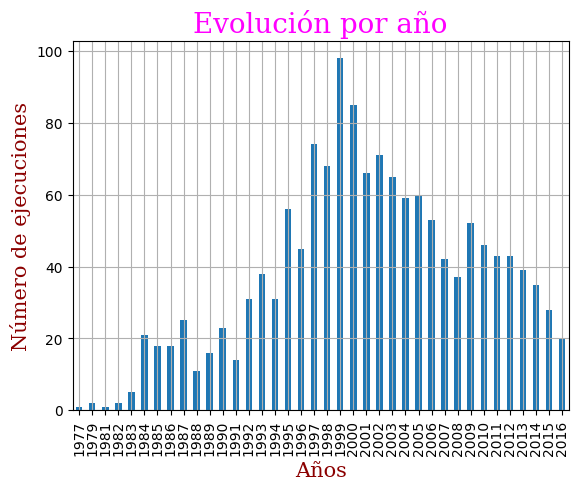

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
font1={'family':'serif','color':'magenta','size':20}
font2={'family':'serif','color':'darkred','size':15}
###Evolución por año (Gráfica con picos o decesos)
df['Years']=pd.to_datetime(df['Date']).dt.year
df.groupby('Years').size().plot(kind='bar')
plt.title("Evolución por año", fontdict=font1)
plt.xlabel("Años", fontdict=font2)
plt.ylabel("Número de ejecuciones",fontdict=font2)
plt.grid(True)
plt.savefig('Evolución por año1.png')
from google.colab import files
files.download("Evolución por año1.png")
plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

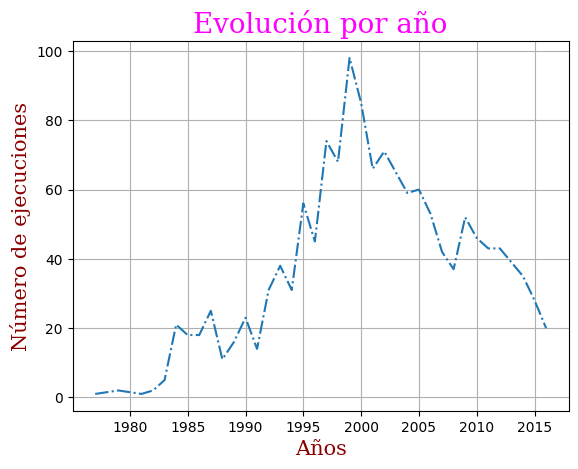

In [15]:
###Grafica ecolucio temporal ############### Gráfica 2
plt.plot(df.groupby('Years').size(),'-.')
plt.title("Evolución por año", fontdict=font1)
plt.xlabel("Años",fontdict=font2)
plt.ylabel("Número de ejecuciones",fontdict=font2)
plt.grid(True)
plt.savefig('Evolución por año.png')
from google.colab import files
files.download("Evolución por año.png")
plt.show()
#

In [16]:
####Comparación entre estados: ¿qué estados concentran más ejecuciones?
df.groupby('State').size().sort_values(ascending=False)


,0
State,
TX,538
OK,112
VA,111
FL,92
MO,87
GA,69
AL,58
OH,53
NC,43


In [17]:
###Descargar tabla de comparación entre estados:
# Guardar el resultado en una variable
tabla = df.groupby('State').size().sort_values(ascending=False)

# Convertir la Serie en DataFrame para exportar
tabla = tabla.reset_index(name='count')

# Exportar a CSV
tabla.to_csv("tabla.csv", index=False)

# Descargar el archivo
from google.colab import files
files.download("tabla.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

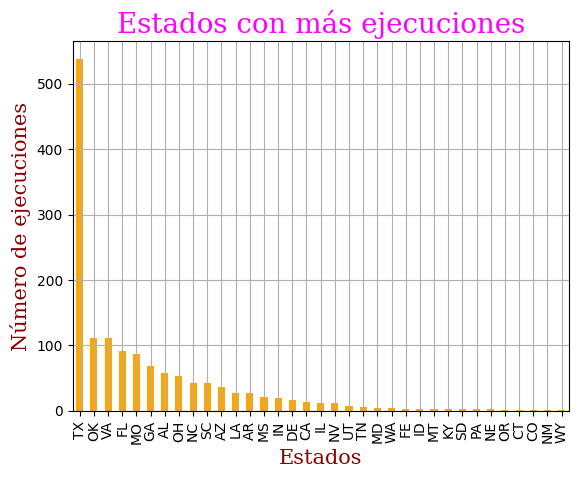

In [18]:
####Comparación entre estados:Gráfica
df.groupby('State').size().sort_values(ascending=False).plot(kind='bar',color='orange')
plt.title("Estados con más ejecuciones",fontdict=font1)
plt.xlabel("Estados",fontdict=font2)
plt.ylabel("Número de ejecuciones",fontdict=font2)
plt.grid(True)
plt.savefig('Estados con más ejecuciones.png')
from google.colab import files
files.download("Estados con más ejecuciones.png")
plt.show()


In [19]:
###Comparación entre regiones
df.groupby('Region').size().sort_values(ascending=False)


,0
Region,
South,1175
Midwest,178
West,85
Northeast,4


In [20]:
###Comparación entre regiones: porcentaje
##df.groupby('Region').size().sort_values(ascending=False)*100
df['Region'].value_counts(normalize=True)*100

,proportion
Region,
South,81.484050
Midwest,12.343967
West,5.894591
Northeast,0.277393


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

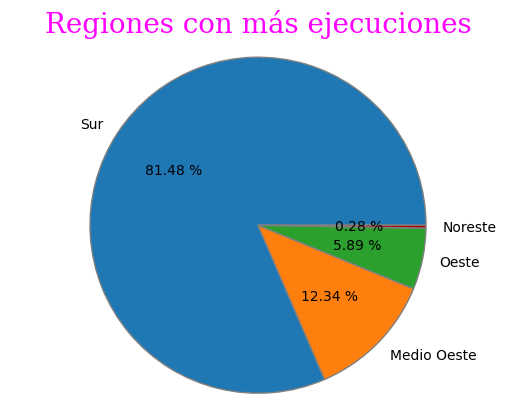

In [27]:
###Comparación entre regiones: Gráfica de pastel
df.groupby('Region').size().sort_values(ascending=False)
etiquetas=["Sur", "Medio Oeste","Oeste","Noreste"]
colores=["#1f77b4", "#ff7f0e","#2ca02c","#A60000"]
porcentajes=df.groupby('Region').size().sort_values(ascending=False)*100
plt.pie(porcentajes,labels=etiquetas,autopct="%0.2f %%", colors=colores, wedgeprops={"edgecolor": "grey", "linewidth": 1})
plt.axis("equal")
plt.title("Regiones con más ejecuciones",fontdict=font1)
plt.savefig('Regiones con más ejecuciones.png')
from google.colab import files
files.download("Regiones con más ejecuciones.png")
plt.show()

2. Características de los ejecutados



In [25]:
####Número de las personas ejecutadas separadas por su sexo
df.groupby('Sex').size().sort_values(ascending=False)

,0
Sex,
Male,1426
Female,16


In [26]:
###Distribución por sexo de los ejecutados: porcentaje
df['Sex'].value_counts()
df['Sex'].value_counts(normalize=True)*100

,proportion
Sex,
Male,98.89043
Female,1.10957


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

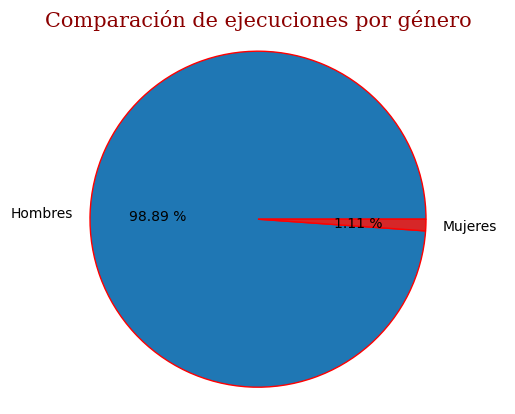

In [28]:
###Distribución por sexo: Grafica
###########################
etiquetas=["Hombres", "Mujeres"]
colores=["#1f77b4", "#d62728"]
porcentajes=df.groupby('Sex').size().sort_values(ascending=False)*100
#####porcentajes=df['Sex'].value_counts(normalize=True)*100
plt.pie(porcentajes,labels=etiquetas,autopct="%0.2f %%", colors=colores, wedgeprops={"edgecolor": "red", "linewidth": 1})
plt.axis("equal")
plt.title("Comparación de ejecuciones por género",fontdict=font2)
plt.savefig('Comparación de ejecuciones por género.png')
from google.colab import files
files.download("Comparación de ejecuciones por género.png")
plt.show()


In [29]:
####Distribución por edad  de los ejecutados
df['Age'].describe()

,Age
count,1442.000000
mean,41.479889
std,9.471676
min,22.000000
25%,34.000000
50%,40.000000
75%,47.000000
max,77.000000


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

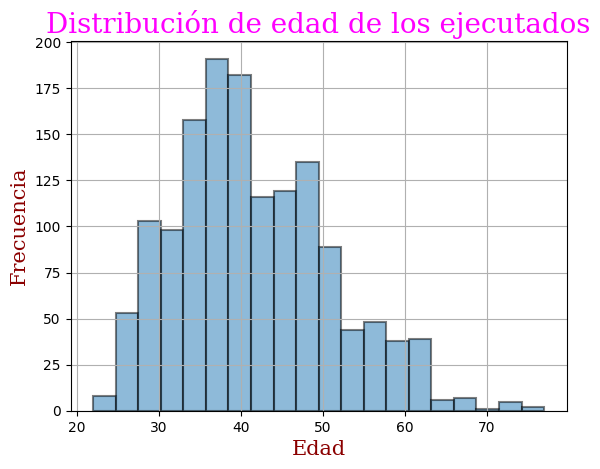

In [30]:
####Distribución por edad  de los ejecutados(promedio, rango, casos juveniles).
df['Age'].describe()
plt.hist(df['Age'],bins=20, edgecolor="black",linewidth=1.5, alpha=0.5)
plt.title("Distribución de edad de los ejecutados", fontdict=font1)
plt.xlabel("Edad", fontdict=font2)
plt.ylabel("Frecuencia", fontdict=font2)
plt.grid(True)
plt.savefig('Distribución de edad de los ejecutados.png')
from google.colab import files
files.download("Distribución de edad de los ejecutados.png")
plt.show()

In [31]:
###Distribución por raza/etnia
df.groupby('Race').size().sort_values(ascending=False)

,0
Race,
White,803
Black,495
Latino,120
Native American,16
Asian,6
Other,2


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

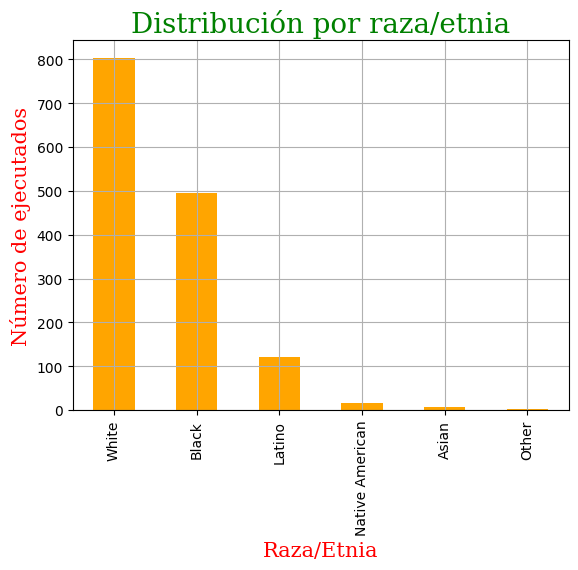

In [32]:
###Distribución por raza/etnia Gráfica
import pandas as pd
import matplotlib.pyplot as plt
link='https://github.com/mike1502/THC/blob/main/Python/BasesDeDatos/EXECUTION_USA.csv'
code='?raw=true'
url=link+code
df=pd.read_csv(url,sep=',',index_col=1)


df.groupby('Race').size().sort_values(ascending=False).plot(kind='bar',color='orange')
font3={'family':'serif','color':'green','size':20}
font4={'family':'serif','color':'red','size':15}

plt.title("Distribución por raza/etnia",fontdict=font3)
plt.xlabel("Raza/Etnia",fontdict=font4)
plt.ylabel("Número de ejecutados",fontdict=font4)
plt.grid(True)
plt.savefig('Distribución por raza_etnia.png')
from google.colab import files
files.download("Distribución por raza_etnia.png")
plt.show()

3. Características de los delitos



In [33]:
### Delitos por el cual fueron condenados
df.groupby('Crime').size().sort_values(ascending=False)


,0
Crime,
Murder,1442


In [34]:
###Número de víctimas por caso
df.groupby('Victim Count').size().sort_values(ascending=False)


,0
Victim Count,
1,1081
2,219
3,86
4,34
5,11
6,6
8,1
9,1
12,1


In [35]:
# Guardar el resultado en una variable
tabla = df.groupby('Victim Count').size().sort_values(ascending=False)
# Convertir la Serie en DataFrame para exportar
tabla = tabla.reset_index(name='count')
# Exportar a CSV
tabla.to_csv("victimas_por_caso.csv", index=False)
# Descargar el archivo
from google.colab import files
files.download("victimas_por_caso.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
df[df['Victim Count'] == 168]

,Date,Age,Sex,Race,Crime,Victim Count,Victim Sex,Victim Race,County,State,Region,Method,Juvenile,Volunteer,Federal,Foreign National
Name,,,,,,,,,,,,,,,,
Timothy McVeigh*,06/11/2001,33,Male,White,Murder,168,NaN,NaN,Oklahoma,FE,South,Lethal Injection,No,Yes,Yes,No


In [37]:
###máximo número de víctimas
df['Victim Count'].max()

168

In [38]:
###Suma total de víctimas registradas
df['Victim Count'].sum()


np.int64(2217)

In [39]:
###Relación entre el perfil del condenado y el de las víctimas (sexo)
df.groupby(['Sex', 'Victim Sex']).size().sort_values(ascending=False)




Sex     Victim Sex       
Male    Male                 620
        Female               591
        1 Male, 1 Female     117
        2 Male, 1 Female      26
        1 Male, 2 Female      25
        3 Male, 1 Female      12
Female  Male                  11
Male    2 Male, 2 Female       9
        1 Male, 3 Female       5
        1 Male, 4 Female       5
        2 Male, 3 Female       3
Female  1 Male, 1 Female       2
        Female                 2
Male    5 Male, 1 Female       2
Female  2 Male, 1 Female       1
Male    1 Male, 5 Female       1
        3 Male, 2 Female       1
        6 Male, 10 Female      1
        3 Male, 3 Female       1
        7 Male, 2 Female       1
        6 Male, 3 Female       1
dtype: int64

In [40]:
# Guardar el resultado en una variable
tabla = df.groupby(['Sex', 'Victim Sex']).size().sort_values(ascending=False)

# Convertir la Serie en DataFrame para exportar
tabla = tabla.reset_index(name='count')

# Exportar a CSV
tabla.to_csv("relacion_sexo.csv", index=False)

# Descargar
from google.colab import files
files.download("relacion_sexo.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
###Relación entre el perfil del condenado y el de las víctimas (Raza o grupo étnico)
df.groupby(['Race', 'Victim Race']).size().sort_values(ascending=False)

Race             Victim Race               
White            White                         735
Black            White                         284
                 Black                         167
Latino           Latino                         57
                 White                          52
White            Black                          21
                 Latino                         19
Black            Latino                         17
Native American  White                          13
Black            Asian                          11
White            1 White, 1 Latino               5
                 Asian                           5
                 1 White, 1 Black                4
Asian            Asian                           4
Black            1 White, 1 Black                4
Latino           Black                           4
                 1 White, 2 Latino               2
                 Asian                           2
Native American  Native American                 2
Asian            White                           2
Latino           1 White, 1 Latino               2
White            2 White, 1 Black                2
                 2 White, 1 Asian                2
Black            1 White, 3 Asian                1
                 1 White, 2 Latino               1
                 1 White, 2 Black                1
                 1 White, 1 Latino               1
                 3 White, 1 Black                1
                 2 White, 6 Black                1
                 2 White, 3 Black                1
                 2 White, 1 Black                1
Other            White                           1
Native American  Latino                          1
Black            4 White, 1 Black                1
Latino           1 White, 8 Latino               1
White            2 White, 2 Asian                1
                 2 White, 1 Latino               1
                 1 White, 2 Black                1
                 1 White, 3 Latino               1
                 4 White, 1 Latino               1
                 4 White, 1 Black, 1 Latino      1
                 3 White, 1 Black                1
                 Native American                 1
dtype: int64

In [42]:
# Guardar el resultado en una variable
tabla = df.groupby(['Race', 'Victim Race']).size().sort_values(ascending=False)

# Convertir la Serie en DataFrame para exportar
tabla = tabla.reset_index(name='count')

# Exportar a CSV
tabla.to_csv("relacion_raza.csv", index=False)

# Descargar el archivo
from google.colab import files
files.download("relacion_raza.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 4. Métodos de ejecución



In [43]:
###Frecuencia de cada método de ejecución(inyección letal, electrocución, etc.).
df.groupby('Method').size().sort_values(ascending=False)

,0
Method,
Lethal Injection,1267
Electrocution,158
Gas Chamber,11
Firing Squad,3
Hanging,3


In [44]:
# Guardar el resultado en una variable
tabla = df.groupby('Method').size().sort_values(ascending=False)

# Convertir la Serie en DataFrame para exportar
tabla = tabla.reset_index(name='count')

# Exportar a CSV
tabla.to_csv("metodos.csv", index=False)

# Descargar
from google.colab import files
files.download("metodos.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

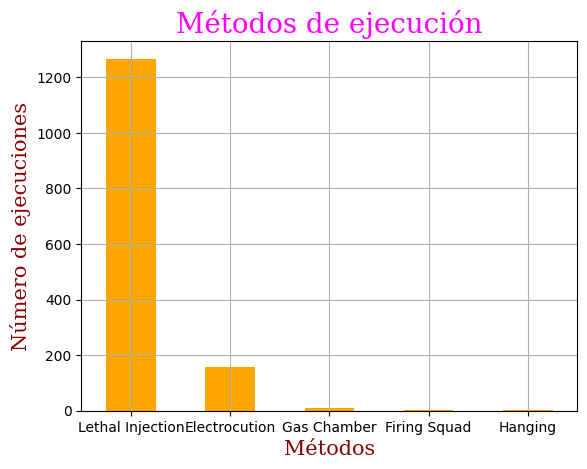

In [54]:
###Frecuencia de cada método de ejecución(inyección letal, electrocución, etc.).
df.groupby('Method').size().sort_values(ascending=False).plot(kind='bar',color='orange')
plt.title("Métodos de ejecución", fontdict=font1)
plt.xlabel("Métodos",fontdict=font2)
plt.ylabel("Número de ejecuciones",fontdict=font2)
plt.xticks(rotation=360)
plt.grid(True)
plt.savefig('Métodos de ejecución.png')
from google.colab import files
files.download("Métodos de ejecución.png")
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

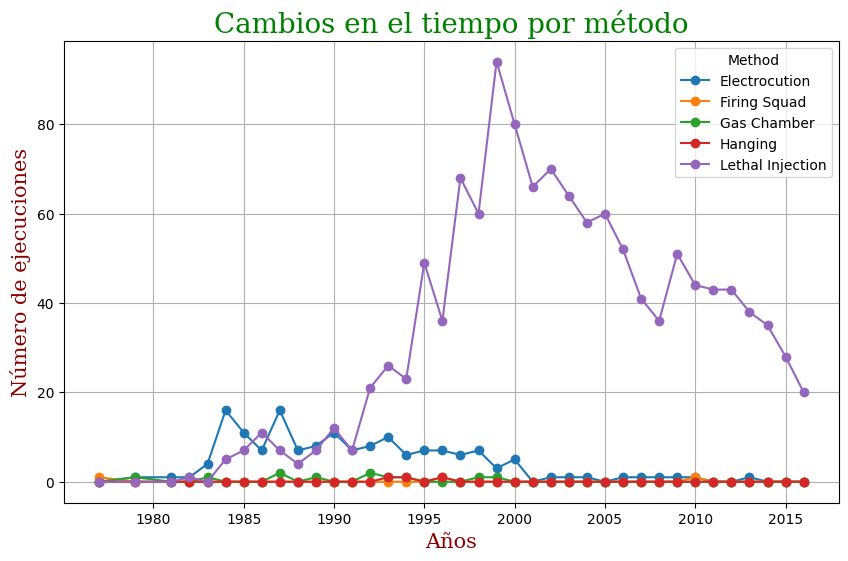

In [55]:
###Cambios en el tiempo en los métodos
df['Years']=pd.to_datetime(df['Date']).dt.year
# Crear tabla de frecuencias por año y método
data = df.groupby(['Years','Method']).size().unstack(fill_value=0)
# Graficar cada método como una línea
data.plot(kind='line', marker='o', figsize=(10,6))
plt.title("Cambios en el tiempo por método", fontdict=font3)
plt.xlabel("Años", fontdict=font2)
plt.ylabel("Número de ejecuciones", fontdict=font2)
plt.grid(True)
plt.savefig('Cambios en el tiempo por método.png')
from google.colab import files
files.download("Cambios en el tiempo por método.png")
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

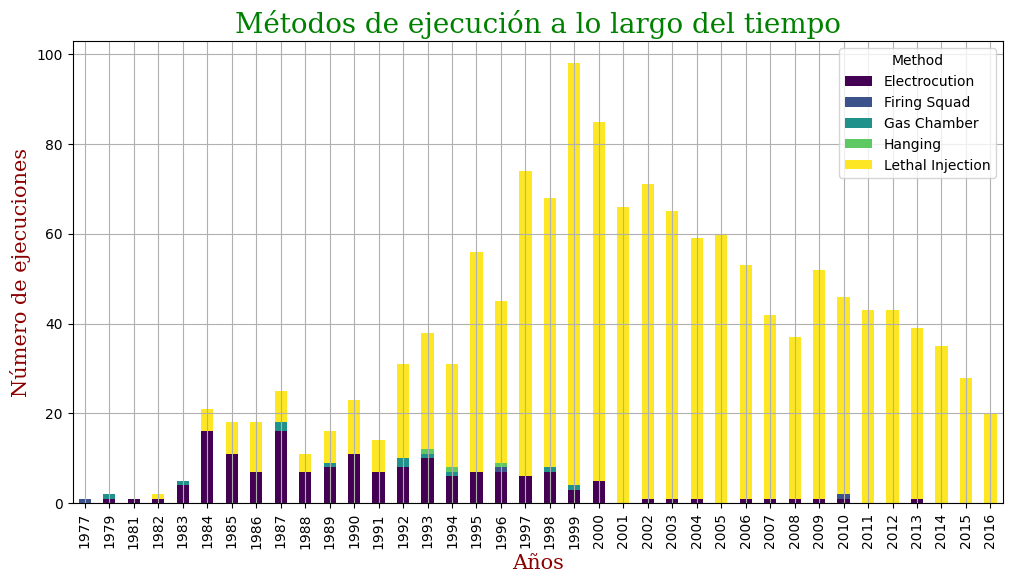

In [56]:
###Cambios en el tiempo
data.plot(kind='bar', stacked=True, figsize=(12,6), colormap='viridis')
plt.title("Métodos de ejecución a lo largo del tiempo", fontdict=font3)
plt.xlabel("Años", fontdict=font2)
plt.ylabel("Número de ejecuciones", fontdict=font2)
plt.grid(True)
plt.savefig('Métodos de ejecución a lo largo del tiempo.png')
from google.colab import files
files.download("Métodos de ejecución a lo largo del tiempo.png")
plt.show()


5. Aspectos especiales

In [57]:
##Cuántos cometieron el delito siendo menores de edad.
df['Juvenile'].value_counts()

,count
Juvenile,
No,1420
Yes,22


In [58]:
##Casos voluntarios: cuántos renunciaron a apelaciones.
df.groupby('Volunteer').size().sort_values(ascending=False)


,0
Volunteer,
No,1297
Yes,145


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

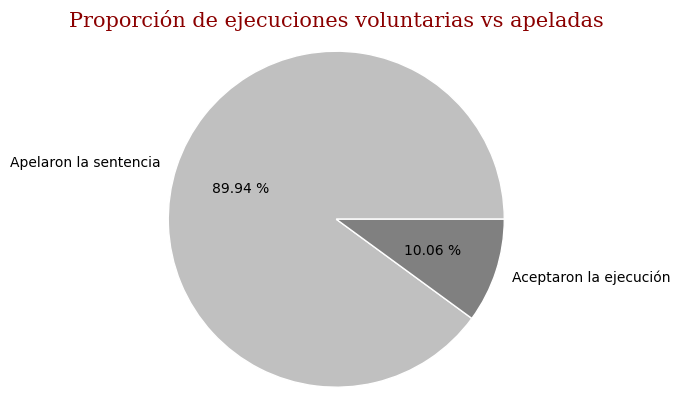

In [59]:
##Casos voluntarios: cuántos renunciaron a apelaciones. Porcentaje
df['Volunteer'].value_counts(normalize=True)*100
etiquetas=["Apelaron la sentencia","Aceptaron la ejecución"]
colores=["silver","gray"]
porcentajes=df.groupby('Volunteer').size().sort_values(ascending=False)*100
plt.pie(porcentajes,labels=etiquetas,autopct="%0.2f %%", colors=colores, wedgeprops={"edgecolor": "white", "linewidth": 1})
plt.axis("equal")
plt.title("Proporción de ejecuciones voluntarias vs apeladas",fontdict=font2)
plt.savefig('Proporción de ejecuciones voluntarias vs apeladas.png')
from google.colab import files
files.download("Proporción de ejecuciones voluntarias vs apeladas.png")
plt.show()


In [60]:
###Casos federales vs estatales.
df['Federal'].value_counts()

,count
Federal,
No,1439
Yes,3


In [61]:
###Presencia de extranjeros ejecutados.
df['Foreign National'].value_counts()

,count
Foreign National,
No,1406
Yes,36


In [62]:
###Presencia de extranjeros ejecutados en los distintos estados.
df.groupby(['State','Foreign National']).size().unstack(fill_value=0)


Foreign National,No,Yes
State,,
AL,58,0
AR,27,0
AZ,34,3
CA,12,1
CO,1,0
CT,1,0
DE,16,0
FE,3,0
FL,87,5


In [63]:
# Guardar el resultado en una variable
tabla = df.groupby(['State','Foreign National']).size().unstack(fill_value=0)

# Exportar a CSV
tabla.to_csv("estado_foreign.csv")

# Descargar
from google.colab import files
files.download("estado_foreign.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

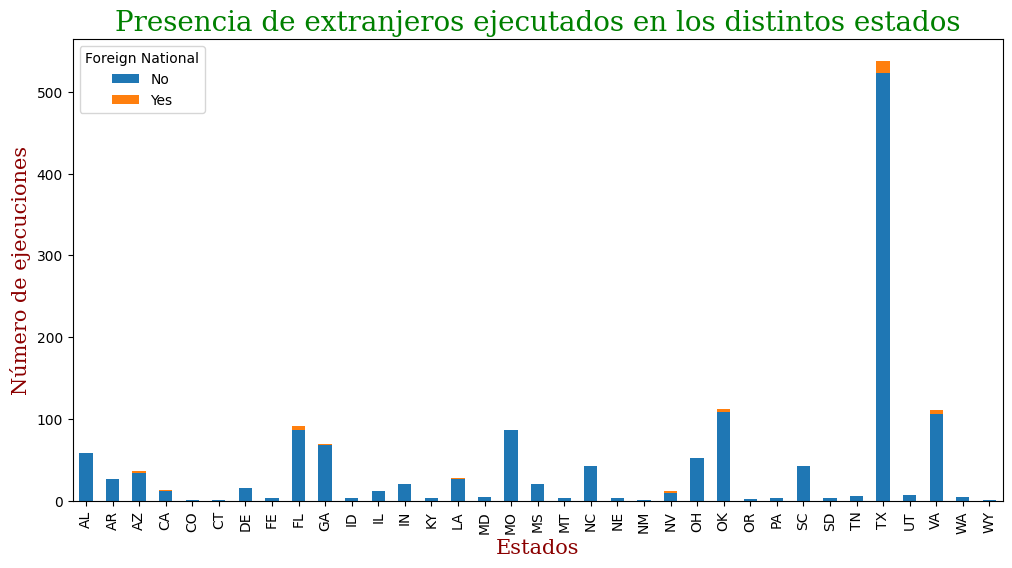

In [64]:
###Presencia de extranjeros ejecutados en los distintos estados. Gráfica
df.groupby(['State','Foreign National']).size().unstack(fill_value=0)
df.groupby(['State','Foreign National']).size().unstack(fill_value=0).plot(kind='bar',stacked=True,figsize=(12,6))
plt.title("Presencia de extranjeros ejecutados en los distintos estados",fontdict=font3)
plt.xlabel("Estados",fontdict=font2)
plt.ylabel("Número de ejecuciones",fontdict=font2)
plt.savefig('Presencia de extranjeros ejecutados en los distintos estados.png')
from google.colab import files
files.download("Presencia de extranjeros ejecutados en los distintos estados.png")
plt.show()

6. Patrones y correlaciones

In [65]:
###Relación entre estado y método de ejecución.
df.groupby(['State','Method']).size().unstack(fill_value=0)

Method,Electrocution,Firing Squad,Gas Chamber,Hanging,Lethal Injection
State,,,,,
AL,24,0,0,0,34
AR,1,0,0,0,26
AZ,0,0,2,0,35
CA,0,0,2,0,11
CO,0,0,0,0,1
CT,0,0,0,0,1
DE,0,0,0,1,15
FE,0,0,0,0,3
FL,44,0,0,0,48


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

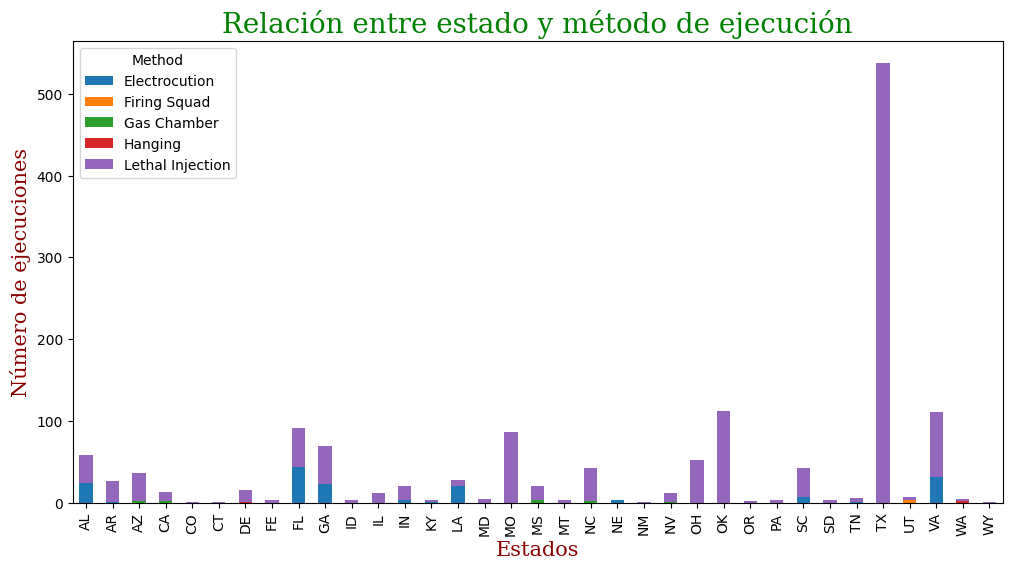

In [66]:
###Relación entre estado y método de ejecución. Gráfica
df.groupby(['State','Method']).size().unstack(fill_value=0).plot(kind='bar',stacked=True,figsize=(12,6))
plt.title("Relación entre estado y método de ejecución",fontdict=font3)
plt.xlabel("Estados",fontdict=font2)
plt.ylabel("Número de ejecuciones",fontdict=font2)
plt.savefig('Relación entre estado y método de ejecución.png')
from google.colab import files
files.download("Relación entre estado y método de ejecución.png")
plt.show()

In [67]:
###Relación entre regiones y método de ejecución.
df.groupby(['Region','Method']).size().unstack(fill_value=0)


Method,Electrocution,Firing Squad,Gas Chamber,Hanging,Lethal Injection
Region,,,,,
Midwest,6,0,0,0,172
Northeast,0,0,0,0,4
South,152,0,6,1,1016
West,0,3,5,2,75


In [68]:
# Guardar el resultado en una variable
tabla = df.groupby(['Region','Method']).size().unstack(fill_value=0)

# Exportar a CSV
tabla.to_csv("region_metodo.csv")

# Descargar
from google.colab import files
files.download("region_metodo.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

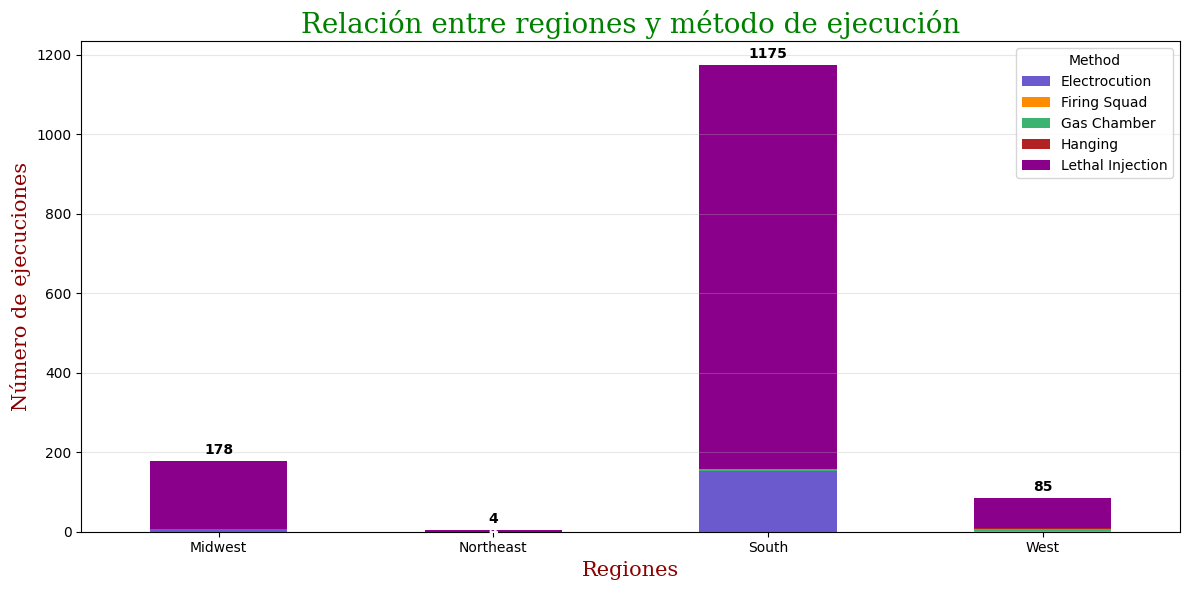

In [76]:
###Relación entre regiones y método de ejecución. Gráfica
df.groupby(['Region','Method']).size().unstack(fill_value=0)
colors = ['#6a5acd','#ff8c00','#3cb371','#b22222','#8b008b']
ax = data.plot(kind='bar', stacked=True, figsize=(12,6), color=colors)

plt.title("Relación entre regiones y método de ejecución", fontdict=font3)
plt.xlabel("Regiones", fontdict=font2)
plt.ylabel("Número de ejecuciones", fontdict=font2)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
# Totales por región
for idx, region in enumerate(data.index):
    total = data.loc[region].sum()
    ax.text(idx, total + 10, str(total),
            ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='black')
# Etiqueta específica para Northeast
for idx, region in enumerate(data.index):
    if region == 'Northeast':
        cumulative = 0
        for method in data.columns:
            value = data.loc[region, method]
            if value > 0:
                cumulative += value
                ax.text(idx, cumulative - value/2, str(value),
                        ha='center', va='center',
                        fontsize=10, fontweight='bold', color='white')
plt.tight_layout()
plt.savefig('Relación entre regiones y método de ejecución.png')
from google.colab import files
files.download("Relación entre regiones y método de ejecución.png")
plt.show()